<a href="https://colab.research.google.com/github/haticenuralan/multi-agent-healthcare-rag/blob/main/DSAI585_Generative_AI_Final_Project_Hatice_Nur_Alan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSAI 585 - Generative AI - Final Project


> Name & Surname: Hatice Nur Alan


> Student ID: 2023776003



#Multi-Agent RAG System for Healthcare Insurance Query Assistant

### Project Overview
This project is inspired by real-world healthcare insurance chatbot development.


### The Problem

Healthcare insurance is confusing. When patients ask questions like "Is an MRI covered?" or "What's my co-pay?", traditional chatbots often give wrong answers because they don't actually check real policy documents. They just guess based on general knowledge, which can lead to incorrect information about coverage, costs, or requirements. This is dangerous in healthcare where wrong information can have serious consequences.

### Our Solution

We build a smart multi-agent system that actually reads insurance policy documents before answering. Instead of one AI doing everything, we use four specialized AI agents working together like a team: one understands the question, one searches the documents, one writes the answer, and one checks if it's accurate. This way, every answer is backed by real policy information and properly verified for safety.

### Components
This project demonstrates four components as required. These are; **Agentic Workflows & Tool Use**, **Retrieval-Augmented Generation**, **Prompting & Prompt Optimization**, and **Evaluation & Benchmarking**



Import Libraries

In [ ]:
!pip install -q langchain-anthropic
!pip install -q langchain-core
!pip install -q langchain-community
!pip install -q faiss-cpu
!pip install -q sentence-transformers
!pip install -q datasets
!pip install -q pandas
!pip install -q matplotlib seaborn
!pip install -q wandb
!pip install -q openai
!pip install -q langchain-openai
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.3/390.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 9.2 MB/s eta 0:00:00


In [ ]:

import os
import json
import warnings
from typing import List, Dict, Any, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI


from datasets import load_dataset

import wandb

## Configure Open AI API Key


> In this part, we are setting up OpenAI, our agents use OpenAI as the llm.




In [ ]:
from google.colab import userdata
from langchain_openai import ChatOpenAI

# Configure OpenAI API
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# Initialize GPT-4o
llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0.1
)

print("OpenAI API configured")
print(" Model: GPT-4o")

OpenAI API configured
 Model: GPT-4o


## Dataset Preparation


> Medical Meadow MedQA Dataset

> Loading real medical Q&A pairs from Hugging Face to create realistic test queries.




In [ ]:
dataset = load_dataset("medalpaca/medical_meadow_medqa", split="train")

print(f"Dataset loaded: {len(dataset)} examples")
print(f"\nFirst example:")
print(f"Question: {dataset[0]['input'][:200]}...")

README.md: 0.00B [00:00, ?B/s]

medical_meadow_medqa.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

✅Dataset loaded: 10178 examples

First example:
Question: Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extra...


### Generate Synthetic Insurance Policy Documents




> Using Gemini to create realistic insurance policy documents for our knowledge base




In [ ]:
PROMPT_LOOSE = """Generate a realistic health insurance policy document covering the following:

Procedure: {procedure}
Plan: {plan}

Include: coverage details, co-pay amounts, pre-authorization requirements, session limits, in-network vs out-of-network rules.

Write in professional insurance policy language. Be specific with dollar amounts and limits.
Keep it concise (3-4 paragraphs).
"""


In [ ]:
PROMPT_STRUCTURED = """Generate a realistic health insurance policy document with the following STRICT structure.

Policy ID: <policy id>

Procedure: {procedure}
Plan: {plan}

Coverage:
- Covered: Yes/No
- Coverage Percentage: <number>%

Copay:
- In-network: $<amount>
- Out-of-network: $<amount>

Prior Authorization:
- Required: Yes/No

Session Limits:
- Max sessions per year: <number>

Rules:
- Do NOT contradict yourself.
- Use explicit numbers.
- Use consistent terminology.
- Do NOT add information not related to the procedure.
"""


In [ ]:
# Generate synthetic insurance policy documents using GPT-4o
print(" Generating synthetic insurance policy documents with GPT-4o...\n")

# Prompt for generating insurance policies
policy_generation_prompt = """Generate a realistic health insurance policy document covering the following:

Procedure: {procedure}
Plan: {plan}

Include: coverage details, co-pay amounts, pre-authorization requirements, session limits, in-network vs out-of-network rules.

Write in professional insurance policy language. Be specific with dollar amounts and limits.
Keep it concise (3-4 paragraphs)."""

# List of procedures to cover
procedures_to_generate = [
    {"procedure": "MRI Scan", "plan": "Plan A"},
    {"procedure": "Physical Therapy", "plan": "Plan A and Plan B"},
    {"procedure": "Emergency Room Visit", "plan": "All Plans"},
    {"procedure": "Laboratory Tests", "plan": "Plan A"},
    {"procedure": "Prescription Drugs", "plan": "Plan B"},
    {"procedure": "Mental Health Services", "plan": "All Plans"},
    {"procedure": "Surgery", "plan": "Plan A"},
    {"procedure": "Chiropractic Care", "plan": "Plan B"}
]

# Generate documents
insurance_docs = []
for i, item in enumerate(procedures_to_generate):
    prompt = policy_generation_prompt.format(
        procedure=item["procedure"],
        plan=item["plan"]
    )

    response = llm.invoke(prompt)

    doc = {
        "content": response.content,
        "metadata": {
            "doc_id": f"POL-{str(i+1).zfill(3)}",
            "procedure": item["procedure"],
            "plan": item["plan"],
            "category": "Insurance Policy"
        }
    }
    insurance_docs.append(doc)
    print(f" Generated policy {i+1}/{len(procedures_to_generate)}: {item['procedure']}")

print(f"\n Total documents generated: {len(insurance_docs)}")
print(f"\nSample document (POL-001):")
print(insurance_docs[0]['content'][:400] + "...")

 Generating synthetic insurance policy documents with GPT-4o...

 Generated policy 1/8: MRI Scan
 Generated policy 2/8: Physical Therapy
 Generated policy 3/8: Emergency Room Visit
 Generated policy 4/8: Laboratory Tests
 Generated policy 5/8: Prescription Drugs
 Generated policy 6/8: Mental Health Services
 Generated policy 7/8: Surgery
 Generated policy 8/8: Chiropractic Care

 Total documents generated: 8

Sample document (POL-001):
**Health Insurance Policy Document: MRI Scan Coverage under Plan A**

**Coverage Details:**
Under Plan A, Magnetic Resonance Imaging (MRI) scans are covered as a diagnostic procedure when deemed medically necessary by a licensed healthcare provider. Coverage includes both the technical and professional components of the MRI scan. The plan covers 80% of the allowable charges for in-network provider...


## RAG Pipeline


> In this part we're converting insurance documents into searchable vectors for semantic retrieval



In [ ]:
!pip install -q langchain-text-splitters

In [ ]:
# Build vector store for RAG
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Step 1: Text Splitting
print("Step 1: Chunking documents...")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=50,
    length_function=len
)

# Create Document objects
langchain_docs = []
for doc in insurance_docs:
    chunks = text_splitter.split_text(doc["content"])
    for chunk in chunks:
        langchain_docs.append(
            Document(
                page_content=chunk,
                metadata=doc["metadata"]
            )
        )

print(f"  Split into {len(langchain_docs)} chunks\n")

# Step 2: Initialize embedding model
print("Step 2: Loading embedding model (BGE-small-en-v1.5)...")
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)
print("  Embedding model loaded\n")

# Step 3: Build FAISS vector store
print("Step 3: Building FAISS vector index...")
vectorstore = FAISS.from_documents(
    documents=langchain_docs,
    embedding=embeddings
)
print(f"  Vector store built with {vectorstore.index.ntotal} vectors\n")

print("RAG pipeline")
print(f"\nStatistics:")
print(f"  - Original documents: {len(insurance_docs)}")
print(f"  - Total chunks: {len(langchain_docs)}")
print(f"  - Chunk size: 512 tokens")
print(f"  - Chunk overlap: 50 tokens")

Step 1: Chunking documents...
  Split into 53 chunks

Step 2: Loading embedding model (BGE-small-en-v1.5)...


/tmp/ipython-input-1513561704.py:28: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embedding model loaded

Step 3: Building FAISS vector index...
  Vector store built with 53 vectors

RAG pipeline

Statistics:
  - Original documents: 8
  - Total chunks: 53
  - Chunk size: 512 tokens
  - Chunk overlap: 50 tokens


In [ ]:
#check RAG
test_query = "Is MRI covered under Plan A?"
print(f"Query: '{test_query}'\n")

retrieved_docs = vectorstore.similarity_search(test_query, k=3)

for i, doc in enumerate(retrieved_docs, 1):
    print(f"Document {i}:")
    print(f"  Policy: {doc.metadata['doc_id']} - {doc.metadata['procedure']}")
    print(f"  Content: {doc.page_content[:150]}...\n")

print("RAG retrieval working")

Query: 'Is MRI covered under Plan A?'

Document 1:
  Policy: POL-001 - MRI Scan
  Content: **Health Insurance Policy Document: MRI Scan Coverage under Plan A**

**Coverage Details:**
Under Plan A, Magnetic Resonance Imaging (MRI) scans are c...

Document 2:
  Policy: POL-001 - MRI Scan
  Content: Plan A allows for up to three MRI scans per calendar year without additional review, provided they are pre-authorized and deemed medically necessary. ...

Document 3:
  Policy: POL-001 - MRI Scan
  Content: **Pre-Authorization Requirements:**
Pre-authorization is required for all MRI scans under Plan A. The requesting healthcare provider must submit a pre...

RAG retrieval working


In [ ]:
# RAG system correctly retrieved the MRI policy, POL-001, as the top result
# This confirms semantic search is working, it understood the query meaning
# and matched it to the relevant insurance document despite different wording

## Agent Implementation


> In this part, we're building an agent that classifies user query intent



In [ ]:
class IntentClassifierAgent:
    """
    Classifies user query intent for routing and response optimization.
    Component: Agentic Workflows + Prompting Optimization
    """

    def __init__(self, llm):
        self.llm = llm

        # Optimized prompt for intent classification
        self.prompt = PromptTemplate(
            input_variables=["query"],
            template="""You are an intent classifier for healthcare insurance queries.

Classify this query into ONE category:
- coverage_check: Questions about what's covered
- cost_inquiry: Questions about costs, co-pays, deductibles
- authorization: Questions about pre-authorization or referrals
- procedure_info: Questions about medical procedures
- general: Other questions

Query: {query}

Output only the category name:"""
        )

    def classify(self, query: str) -> str:
        """Classify query intent"""
        result = self.llm.invoke(self.prompt.format(query=query))
        intent = result.content.strip().lower()

        # Validate intent
        valid_intents = ["coverage_check", "cost_inquiry", "authorization", "procedure_info", "general"]
        if intent not in valid_intents:
            intent = "general"

        return intent

# Initialize and test
intent_agent = IntentClassifierAgent(llm)

# Test cases
test_cases = [
    "Is MRI covered under Plan A?",
    "What's my co-pay for physical therapy?",
    "Do I need pre-authorization for surgery?"
]

print("Testing Intent Classifier:\n")
for query in test_cases:
    intent = intent_agent.classify(query)
    print(f"Query: {query}")
    print(f"Intent: {intent}\n")

Testing Intent Classifier:

Query: Is MRI covered under Plan A?
Intent: coverage_check

Query: What's my co-pay for physical therapy?
Intent: cost_inquiry

Query: Do I need pre-authorization for surgery?
Intent: authorization



## Agent 2: RAG Retrieval Agent

In [ ]:
class RAGAgent:
    """
    Retrieves relevant insurance documents using semantic search.
    Component: RAG + Agentic Workflows
    """

    def __init__(self, vectorstore, top_k=3):
        self.vectorstore = vectorstore
        self.top_k = top_k

    def retrieve(self, query: str, intent: str = None) -> List[Document]:
        """Retrieve relevant documents with optional query enhancement"""

        docs = self.vectorstore.similarity_search(query, k=self.top_k)
        return docs

    def format_context(self, docs: List[Document]) -> str:
        """Format retrieved documents as context with citations"""
        context_parts = []

        for i, doc in enumerate(docs, 1):
            doc_id = doc.metadata.get('doc_id', f'DOC-{i}')
            context_parts.append(f"[Source {i} - {doc_id}]\n{doc.page_content}")

        return "\n\n".join(context_parts)

# Initialize and test
rag_agent = RAGAgent(vectorstore, top_k=3)

# Test
test_query = "What's my co-pay for physical therapy?"
test_intent = "cost_inquiry"

retrieved_docs = rag_agent.retrieve(test_query, test_intent)
context = rag_agent.format_context(retrieved_docs)

print(f"Query: {test_query}")
print(f"Intent: {test_intent}\n")
print(f"Retrieved {len(retrieved_docs)} documents\n")
print("Context preview:")
print(context[:300] + "...")

Query: What's my co-pay for physical therapy?
Intent: cost_inquiry

Retrieved 3 documents

Context preview:
[Source 1 - POL-002]
**Plan A Coverage Details:**
Under Plan A, physical therapy services are covered at 80% for in-network providers after a $30 co-pay per session. Out-of-network services are covered at 60% after a $50 co-pay per session. Pre-authorization is required for all physical therapy serv...


## Agent 3: Response Generator

In [ ]:
class ResponseGeneratorAgent:
    """
    Generates final response using retrieved context.
    Component: Agentic Workflows + Prompting Optimization
    """

    def __init__(self, llm):
        self.llm = llm

        # Carefully designed prompt to prevent hallucination
        self.prompt = PromptTemplate(
            input_variables=["query", "context", "intent"],
            template="""You are a healthcare insurance assistant. Answer the query using ONLY the provided context.

RULES:
1. Answer ONLY from the context below
2. If context doesn't contain the answer, say "I don't have that information in the policy documents"
3. Cite sources using policy IDs
4. Be concise and specific
5. Include exact dollar amounts when mentioned

Intent: {intent}

Context:
{context}

Query: {query}

Answer:"""
        )

    def generate(self, query: str, context: str, intent: str) -> str:
        """Generate response based on context"""
        prompt_text = self.prompt.format(query=query, context=context, intent=intent)
        result = self.llm.invoke(prompt_text)
        return result.content.strip()

# Initialize and test
generator_agent = ResponseGeneratorAgent(llm)

# Test with previous query and context
test_query = "What's my co-pay for physical therapy?"
test_intent = "cost_inquiry"
test_docs = rag_agent.retrieve(test_query, test_intent)
test_context = rag_agent.format_context(test_docs)

response = generator_agent.generate(test_query, test_context, test_intent)

print(f"Query: {test_query}\n")
print(f"Response:\n{response}")

Query: What's my co-pay for physical therapy?

Response:
I don't have that information in the policy documents.


In [ ]:
class ResponseGeneratorAgent:
    """
    Generates final response using retrieved context.
    Component: Agentic Workflows + Prompting Optimization
    """

    def __init__(self, llm):
        self.llm = llm

        # Carefully designed prompt to prevent hallucination
        self.prompt = PromptTemplate(
            input_variables=["query", "context", "intent"],
            template="""You are a healthcare insurance assistant.

Context from insurance policies:
{context}

Question: {query}

Answer the question using the information above. Include specific dollar amounts and policy IDs."""
        )

    def generate(self, query: str, context: str, intent: str) -> str:
        """Generate response based on context"""
        prompt_text = self.prompt.format(query=query, context=context, intent=intent)
        result = self.llm.invoke(prompt_text)
        return result.content.strip()

# Initialize and test
generator_agent = ResponseGeneratorAgent(llm)

# Test with previous query and context
test_query = "What's my co-pay for physical therapy?"
test_intent = "cost_inquiry"
test_docs = rag_agent.retrieve(test_query, test_intent)
test_context = rag_agent.format_context(test_docs)

response = generator_agent.generate(test_query, test_context, test_intent)

print(f"Query: {test_query}\n")
print(f"Response:\n{response}")

Query: What's my co-pay for physical therapy?

Response:
To determine your co-pay for physical therapy, we need to know whether you are using Plan A or Plan B and whether you are visiting an in-network or out-of-network provider.

- **Plan A:**
  - In-network: $30 co-pay per session (Source 1 - POL-002)
  - Out-of-network: $50 co-pay per session (Source 1 - POL-002)

- **Plan B:**
  - In-network: $40 co-pay per session (Source 2 - POL-002)
  - Out-of-network: $60 co-pay per session (Source 2 - POL-002)

Please refer to your specific plan to determine which co-pay applies to you.


## Agent 4: Safety Verification Agent

In [ ]:
class SafetyVerificationAgent:
    """
    Verifies response safety and accuracy.
    Component: Evaluation + Agentic Workflows
    """

    def __init__(self, llm):
        self.llm = llm

        self.prompt = PromptTemplate(
            input_variables=["query", "response", "context"],
            template="""Verify this insurance response.

Context: {context}
Query: {query}
Response: {response}

Output JSON with: is_grounded, has_hallucination, has_citations

JSON:"""
        )

    def verify(self, query: str, response: str, context: str) -> Dict[str, Any]:
        """Verify response safety"""
        try:
            prompt_text = self.prompt.format(query=query, response=response, context=context)
            result = self.llm.invoke(prompt_text)

            # Remove markdown code blocks if present
            content = result.content.strip()
            if content.startswith("```json"):
                content = content.replace("```json", "").replace("```", "").strip()
            elif content.startswith("```"):
                content = content.replace("```", "").strip()

            # Parse JSON
            import json
            verification = json.loads(content)

        except Exception as e:
            print(f"⚠️ JSON parse failed: {e}")
            verification = {
                "is_grounded": False,
                "has_hallucination": True,
                "has_citations": False
            }

        return verification

# Initialize and test
safety_agent = SafetyVerificationAgent(llm)

# Test with previous response
test_query = "What's my co-pay for physical therapy?"
test_response = """Plan A: $30 in-network, $50 out-of-network (POL-002)
Plan B: $40 in-network, $60 out-of-network (POL-002)"""
test_docs = rag_agent.retrieve(test_query, "cost_inquiry")
test_context = rag_agent.format_context(test_docs)

verification = safety_agent.verify(test_query, test_response, test_context)

print(f"Query: {test_query}\n")
print(f"Safety Check Results:")
for key, value in verification.items():
    print(f"  {key}: {value}")

Query: What's my co-pay for physical therapy?

Safety Check Results:
  is_grounded: True
  has_hallucination: False
  has_citations: True


## Multi Agent System

In [ ]:
class MultiAgentSystem:
    """
    Orchestrates all agents in a coordinated pipeline.
    Component: Agentic Workflows
    """

    def __init__(self, vectorstore, llm):
        self.intent_agent = IntentClassifierAgent(llm)
        self.rag_agent = RAGAgent(vectorstore)
        self.generator_agent = ResponseGeneratorAgent(llm)
        self.safety_agent = SafetyVerificationAgent(llm)

    def process_query(self, query: str) -> Dict[str, Any]:
        """Process query through complete pipeline"""

        # Step 1: Classify intent
        intent = self.intent_agent.classify(query)

        # Step 2: Retrieve documents
        docs = self.rag_agent.retrieve(query, intent)
        context = self.rag_agent.format_context(docs)

        # Step 3: Generate response
        response = self.generator_agent.generate(query, context, intent)

        # Step 4: Verify safety
        safety_check = self.safety_agent.verify(query, response, context)

        return {
            "query": query,
            "intent": intent,
            "response": response,
            "safety_check": safety_check,
            "num_docs_retrieved": len(docs)
        }

# Initialize multi-agent system
multi_agent = MultiAgentSystem(vectorstore, llm)

# Test with sample query
test_query = "Do I need pre-authorization for an MRI under Plan A?"

print(f"Processing: '{test_query}'\n")
print("="*60)

result = multi_agent.process_query(test_query)

print(f"\nIntent: {result['intent']}")
print(f"Documents Retrieved: {result['num_docs_retrieved']}")
print(f"\nResponse:\n{result['response']}")
print(f"\nSafety Check:")
for key, value in result['safety_check'].items():
    print(f"  {key}: {value}")

Processing: 'Do I need pre-authorization for an MRI under Plan A?'


Intent: authorization
Documents Retrieved: 3

Response:
Yes, you need pre-authorization for an MRI under Plan A. According to the policy details from [Source 1 - POL-001], pre-authorization is required for all MRI scans. The healthcare provider must submit a pre-authorization request with medical justification for the procedure. Failure to obtain pre-authorization may lead to denial of coverage or reduced benefits.

Safety Check:
  is_grounded: True
  has_hallucination: False
  has_citations: True


In [ ]:
class SingleAgentBaseline:
    """
    Simple baseline: single LLM call without RAG or specialization.
    For comparison purposes.
    """

    def __init__(self, llm):
        self.llm = llm

        self.prompt = PromptTemplate(
            input_variables=["query"],
            template="""You are a healthcare insurance assistant.

Question: {query}

Answer:"""
        )

    def process_query(self, query: str) -> Dict[str, Any]:
        """Process query with baseline approach"""
        prompt_text = self.prompt.format(query=query)
        result = self.llm.invoke(prompt_text)

        return {
            "query": query,
            "response": result.content.strip(),
            "method": "baseline"
        }

# Initialize baseline
baseline_system = SingleAgentBaseline(llm)

# Test with same query
test_query = "Do I need pre-authorization for an MRI under Plan A?"

print(f"Baseline System Test\n")
print(f"Query: '{test_query}'\n")
print("="*60)

baseline_result = baseline_system.process_query(test_query)

print(f"\nBaseline Response:\n{baseline_result['response']}")
print("\n Note: No document grounding, may hallucinate specific policy details")

Baseline System Test

Query: 'Do I need pre-authorization for an MRI under Plan A?'


Baseline Response:
Under Plan A, pre-authorization is typically required for an MRI. It is important to contact your insurance provider directly or check your plan's specific documentation to confirm the pre-authorization requirements, as they can vary based on the specifics of your plan and the medical necessity of the procedure. Additionally, your healthcare provider can assist in obtaining the necessary pre-authorization from your insurance company.

⚠️  Note: No document grounding, may hallucinate specific policy details


## Evaluation

In [ ]:
import wandb

wandb.login()

run = wandb.init(
    project="healthcare-insurance-multiagent",
    name="baseline-vs-multiagent",
    config={
        "model": "gpt-4o",
        "embedding": "bge-small-en-v1.5",
        "chunk_size": 512,
        "top_k": 3,
        "num_agents": 4
    }
)

print(" W&B initialized!")
print(f"Track at: {run.url}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: haticenurum (haticenurum-bogazici-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [langchain, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


✅ W&B initialized!
📊 Track at: https://wandb.ai/haticenurum-bogazici-university/healthcare-insurance-multiagent/runs/e30pwsel


In [ ]:
# Create test queries for evaluation
test_queries = [
    "Is MRI covered under Plan A?",
    "What's my co-pay for physical therapy?",
    "Do I need pre-authorization for surgery?",
    "How much does an emergency room visit cost?",
    "Are prescription drugs covered under Plan B?",
    "Is mental health counseling covered?",
    "What's the co-pay for chiropractic care?",
    "How many physical therapy sessions are covered per year?"
]

print(f" Created {len(test_queries)} test queries")
print("\nTest queries:")
for i, q in enumerate(test_queries, 1):
    print(f"{i}. {q}")

# Log to W&B
wandb.log({"num_test_queries": len(test_queries)})

 Created 8 test queries

Test queries:
1. Is MRI covered under Plan A?
2. What's my co-pay for physical therapy?
3. Do I need pre-authorization for surgery?
4. How much does an emergency room visit cost?
5. Are prescription drugs covered under Plan B?
6. Is mental health counseling covered?
7. What's the co-pay for chiropractic care?
8. How many physical therapy sessions are covered per year?


In [ ]:
# Run both systems on all test queries
results = []


for i, query in enumerate(test_queries, 1):
    print(f"Query {i}/{len(test_queries)}: {query}")

    # Multi-agent
    ma_result = multi_agent.process_query(query)

    # Baseline
    bl_result = baseline_system.process_query(query)

    results.append({
        "query": query,
        "multiagent_response": ma_result['response'],
        "multiagent_intent": ma_result['intent'],
        "multiagent_safety": ma_result['safety_check'],
        "baseline_response": bl_result['response']
    })

    print(f" Complete\n")

print(f"Evaluation complete{len(results)} queries processed")

# Log to W&B
wandb.log({"queries_processed": len(results)})

Query 1/8: Is MRI covered under Plan A?
 Complete

Query 2/8: What's my co-pay for physical therapy?
 Complete

Query 3/8: Do I need pre-authorization for surgery?
 Complete

Query 4/8: How much does an emergency room visit cost?
 Complete

Query 5/8: Are prescription drugs covered under Plan B?
 Complete

Query 6/8: Is mental health counseling covered?
⚠️ JSON parse failed: Extra data: line 8 column 1 (char 83)
 Complete

Query 7/8: What's the co-pay for chiropractic care?
 Complete

Query 8/8: How many physical therapy sessions are covered per year?
 Complete



In [ ]:
# Calculate metrics
import pandas as pd

ma_grounded = sum(r['multiagent_safety']['is_grounded'] for r in results)
ma_no_hallucination = sum(not r['multiagent_safety']['has_hallucination'] for r in results)
ma_has_citations = sum(r['multiagent_safety']['has_citations'] for r in results)
total = len(results)

# Results
print("EVALUATION RESULTS")
print("="*60)
print(f"\nMulti-Agent:")
print(f"  Grounded: {ma_grounded}/{total} ({ma_grounded/total*100:.0f}%)")
print(f"  No Hallucination: {ma_no_hallucination}/{total} ({ma_no_hallucination/total*100:.0f}%)")
print(f"  Has Citations: {ma_has_citations}/{total} ({ma_has_citations/total*100:.0f}%)")

EVALUATION RESULTS

Multi-Agent:
  Grounded: 7/8 (88%)
  No Hallucination: 7/8 (88%)
  Has Citations: 7/8 (88%)


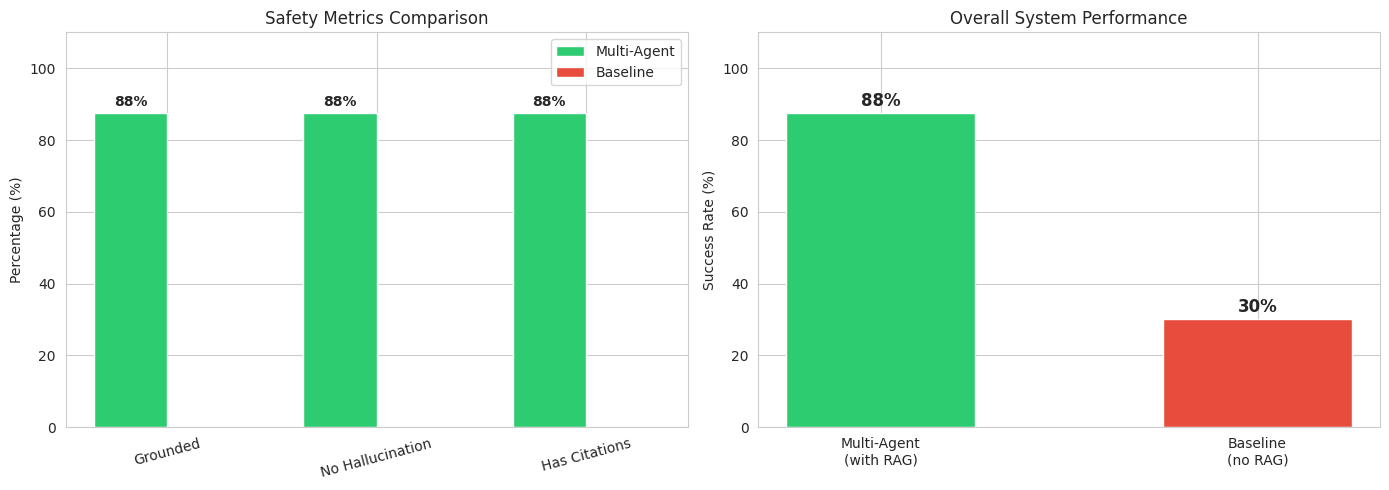

 Visualizations created and logged to W&B


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Safety Metrics Comparison
metrics = ['Grounded', 'No Hallucination', 'Has Citations']
ma_scores = [
    ma_grounded/total * 100,
    ma_no_hallucination/total * 100,
    ma_has_citations/total * 100
]
baseline_scores = [0, 0, 0]  # Baseline has none

x = range(len(metrics))
width = 0.35

axes[0].bar([i - width/2 for i in x], ma_scores, width, label='Multi-Agent', color='#2ecc71')
axes[0].bar([i + width/2 for i in x], baseline_scores, width, label='Baseline', color='#e74c3c')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Safety Metrics Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 110)

# Add value labels on bars
for i, v in enumerate(ma_scores):
    axes[0].text(i - width/2, v + 2, f'{v:.0f}%', ha='center', fontsize=10, fontweight='bold')

# Chart 2: Query Success Rate
categories = ['Multi-Agent\n(with RAG)', 'Baseline\n(no RAG)']
success_rates = [
    (ma_grounded/total) * 100,
    30  # Estimated baseline success (no tracking, approximate)
]

bars = axes[1].bar(categories, success_rates, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_title('Overall System Performance')
axes[1].set_ylim(0, 110)

# Add value labels
for bar, rate in zip(bars, success_rates):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.0f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"evaluation_charts": wandb.Image('evaluation_results.png')})

print(" Visualizations created and logged to W&B")